In [ ]:
!pip install pennylane --upgrade

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 57.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 54.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 67.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 57.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 57.3 MB/s eta 0:00:00


In [ ]:

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder

import pennylane as qml
from pennylane import numpy as pnp

np.random.seed(42)

In [ ]:
iris = sns.load_dataset('iris')
le = LabelEncoder()
iris['target'] = le.fit_transform(iris['species'])

feature_cols = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

train_list, test_list = [], []
for cls in sorted(iris['target'].unique()):
    cls_data = iris[iris['target'] == cls].sample(frac=1, random_state=42).reset_index(drop=True)
    train_list.append(cls_data.iloc[:40])
    test_list.append(cls_data.iloc[40:50])

train_df = pd.concat(train_list).sample(frac=1, random_state=42).reset_index(drop=True)
test_df  = pd.concat(test_list).sample(frac=1, random_state=42).reset_index(drop=True)

X_train_raw = train_df[feature_cols].values
y_train = train_df['target'].values.astype(int)
X_test_raw = test_df[feature_cols].values
y_test = test_df['target'].values.astype(int)

print("Train:", X_train_raw.shape, "Test:", X_test_raw.shape)
print("Train class counts:", np.bincount(y_train))
print("Test class counts:", np.bincount(y_test))

Train: (120, 4) Test: (30, 4)
Train class counts: [40 40 40]
Test class counts: [10 10 10]


In [ ]:

ENCODINGS = {
    'Angle_4q':        {'type': 'angle',   'n_qubits': 4, 'scaler': MinMaxScaler(feature_range=(0, np.pi))},
    'Amplitude_2q':     {'type': 'amplitude', 'n_qubits': 2, 'scaler': StandardScaler()},
    'DataReupload_4q':  {'type': 'reupload', 'n_qubits': 4, 'scaler': MinMaxScaler(feature_range=(0, np.pi))},
    'IQP_4q':           {'type': 'iqp',     'n_qubits': 4, 'scaler': MinMaxScaler(feature_range=(0, 2*np.pi))},
}

def preprocess(X, cfg, fit_scaler=None):
    scaler = fit_scaler if fit_scaler is not None else cfg['scaler']
    Xs = scaler.transform(X) if fit_scaler is not None else scaler.fit_transform(X)
    return Xs, scaler

In [ ]:
def get_observables(n_qubits):
    """3 expectation values -> 3 Iris classes, regardless of qubit count."""
    if n_qubits >= 3:
        return [qml.PauliZ(0), qml.PauliZ(1), qml.PauliZ(2)]
    else:
        return [qml.PauliZ(0), qml.PauliZ(1), qml.PauliZ(0) @ qml.PauliZ(1)]


def apply_ansatz(weights_layer, ansatz, n_qubits):
    if ansatz == 'strong':
        qml.StronglyEntanglingLayers(weights_layer, wires=range(n_qubits))
    elif ansatz == 'basic':
        qml.BasicEntanglerLayers(weights_layer, wires=range(n_qubits))
    else:
        raise ValueError("ansatz must be 'strong' or 'basic'")


def make_circuit(enc_type, ansatz, n_qubits, n_layers):
    dev = qml.device('default.qubit', wires=n_qubits)
    obs = get_observables(n_qubits)

    @qml.qnode(dev)
    def circuit(weights, x):
        if enc_type == 'angle':
            qml.AngleEmbedding(x, wires=range(n_qubits), rotation='Y')
            apply_ansatz(weights, ansatz, n_qubits)

        elif enc_type == 'amplitude':
            qml.AmplitudeEmbedding(x, wires=range(n_qubits), normalize=True, pad_with=0.0)
            apply_ansatz(weights, ansatz, n_qubits)

        elif enc_type == 'iqp':
            qml.IQPEmbedding(x, wires=range(n_qubits), n_repeats=2)
            apply_ansatz(weights, ansatz, n_qubits)

        elif enc_type == 'reupload':

            for l in range(n_layers):
                qml.AngleEmbedding(x, wires=range(n_qubits), rotation='Y')

                layer_w = weights[l:l+1] if ansatz == 'strong' else weights[l:l+1]
                apply_ansatz(layer_w, ansatz, n_qubits)

        else:
            raise ValueError(f"Unknown encoding type: {enc_type}")

        return [qml.expval(o) for o in obs]

    return circuit


def get_weight_shape(enc_type, ansatz, n_layers, n_qubits):
    if ansatz == 'strong':
        base_shape = qml.StronglyEntanglingLayers.shape(n_layers=n_layers, n_wires=n_qubits)
    else:
        base_shape = qml.BasicEntanglerLayers.shape(n_layers=n_layers, n_wires=n_qubits)

    return base_shape

In [ ]:
def softmax(logits):
    e = pnp.exp(logits - pnp.max(logits))
    return e / pnp.sum(e)


def cross_entropy_loss(weights, bias, circuit, X, Y):
    loss = 0.0
    for x, y in zip(X, Y):
        logits = pnp.array(circuit(weights, x)) + bias
        probs = softmax(logits)
        loss = loss - pnp.log(probs[y] + 1e-9)
    return loss / len(X)


def accuracy(weights, bias, circuit, X, Y):
    correct = 0
    for x, y in zip(X, Y):
        logits = pnp.array(circuit(weights, x)) + bias
        pred = int(pnp.argmax(logits))
        if pred == y:
            correct += 1
    return correct / len(X)


def train_model(cfg, ansatz, X_train_raw, y_train, X_test_raw, y_test,
                 n_layers=2, epochs=12, batch_size=10, lr=0.08, seed=42):

    Xtr, scaler = preprocess(X_train_raw, cfg)
    Xte, _ = preprocess(X_test_raw, cfg, fit_scaler=scaler)

    enc_type = cfg['type']
    n_qubits = cfg['n_qubits']

    circuit = make_circuit(enc_type, ansatz, n_qubits, n_layers)
    shape = get_weight_shape(enc_type, ansatz, n_layers, n_qubits)

    np.random.seed(seed)
    weights = pnp.array(np.random.uniform(0, 2 * np.pi, size=shape), requires_grad=True)
    bias = pnp.array(np.zeros(3), requires_grad=True)

    opt = qml.AdamOptimizer(stepsize=lr)
    n_train = len(Xtr)

    for epoch in range(epochs):
        perm = np.random.permutation(n_train)
        Xtr_shuf, ytr_shuf = Xtr[perm], y_train[perm]

        for i in range(0, n_train, batch_size):
            Xb = Xtr_shuf[i:i + batch_size]
            yb = ytr_shuf[i:i + batch_size]

            def cost_fn(w, b):
                return cross_entropy_loss(w, b, circuit, Xb, yb)

            (weights, bias), cost_val = opt.step_and_cost(cost_fn, weights, bias)

        if (epoch + 1) % 4 == 0 or epoch == 0:
            print(f"  epoch {epoch+1:2d}/{epochs} - loss: {float(cost_val):.4f}")

    train_acc = accuracy(weights, bias, circuit, Xtr, y_train)
    test_acc = accuracy(weights, bias, circuit, Xte, y_test)
    return train_acc, test_acc

In [ ]:
MODELS = ['strong', 'basic']
results = []

for enc_name, cfg in ENCODINGS.items():
    for ansatz in MODELS:
        print(f"\n=== Encoding: {enc_name} | Model: {ansatz} ===")
        train_acc, test_acc = train_model(
            cfg, ansatz, X_train_raw, y_train, X_test_raw, y_test,
            n_layers=2, epochs=12, batch_size=10, lr=0.08
        )
        print(f"  -> Train Acc: {train_acc:.3f} | Test Acc: {test_acc:.3f}")
        results.append({
            'Encoding': enc_name,
            'Model': 'StronglyEntangling' if ansatz == 'strong' else 'BasicEntangler',
            'Train_Acc': train_acc,
            'Test_Acc': test_acc
        })

results_df = pd.DataFrame(results)
results_df


=== Encoding: Angle_4q | Model: strong ===
  epoch  1/12 - loss: 0.9583
  epoch  4/12 - loss: 0.8481
  epoch  8/12 - loss: 0.7197
  epoch 12/12 - loss: 0.7268
  -> Train Acc: 0.933 | Test Acc: 0.967

=== Encoding: Angle_4q | Model: basic ===
  epoch  1/12 - loss: 1.0905
  epoch  4/12 - loss: 1.0317
  epoch  8/12 - loss: 0.9950
  epoch 12/12 - loss: 0.9208
  -> Train Acc: 0.617 | Test Acc: 0.700

=== Encoding: Amplitude_2q | Model: strong ===
  epoch  1/12 - loss: 1.2322
  epoch  4/12 - loss: 1.0074
  epoch  8/12 - loss: 0.9327
  epoch 12/12 - loss: 0.9801
  -> Train Acc: 0.642 | Test Acc: 0.700

=== Encoding: Amplitude_2q | Model: basic ===
  epoch  1/12 - loss: 0.8693
  epoch  4/12 - loss: 1.0058
  epoch  8/12 - loss: 0.9299
  epoch 12/12 - loss: 1.0222
  -> Train Acc: 0.558 | Test Acc: 0.667

=== Encoding: DataReupload_4q | Model: strong ===
  epoch  1/12 - loss: 0.8836
  epoch  4/12 - loss: 0.7392
  epoch  8/12 - loss: 0.6220
  epoch 12/12 - loss: 0.5863
  -> Train Acc: 0.967 | Tes

,Encoding,Model,Train_Acc,Test_Acc
0,Angle_4q,StronglyEntangling,0.933333,0.966667
1,Angle_4q,BasicEntangler,0.616667,0.700000
2,Amplitude_2q,StronglyEntangling,0.641667,0.700000
3,Amplitude_2q,BasicEntangler,0.558333,0.666667
4,DataReupload_4q,StronglyEntangling,0.966667,0.966667
5,DataReupload_4q,BasicEntangler,0.833333,0.733333
6,IQP_4q,StronglyEntangling,0.550000,0.600000
7,IQP_4q,BasicEntangler,0.541667,0.400000


       Encoding              Model  Train_Acc  Test_Acc
       Angle_4q StronglyEntangling   0.933333  0.966667
DataReupload_4q StronglyEntangling   0.966667  0.966667
DataReupload_4q     BasicEntangler   0.833333  0.733333
       Angle_4q     BasicEntangler   0.616667  0.700000
   Amplitude_2q StronglyEntangling   0.641667  0.700000
   Amplitude_2q     BasicEntangler   0.558333  0.666667
         IQP_4q StronglyEntangling   0.550000  0.600000
         IQP_4q     BasicEntangler   0.541667  0.400000


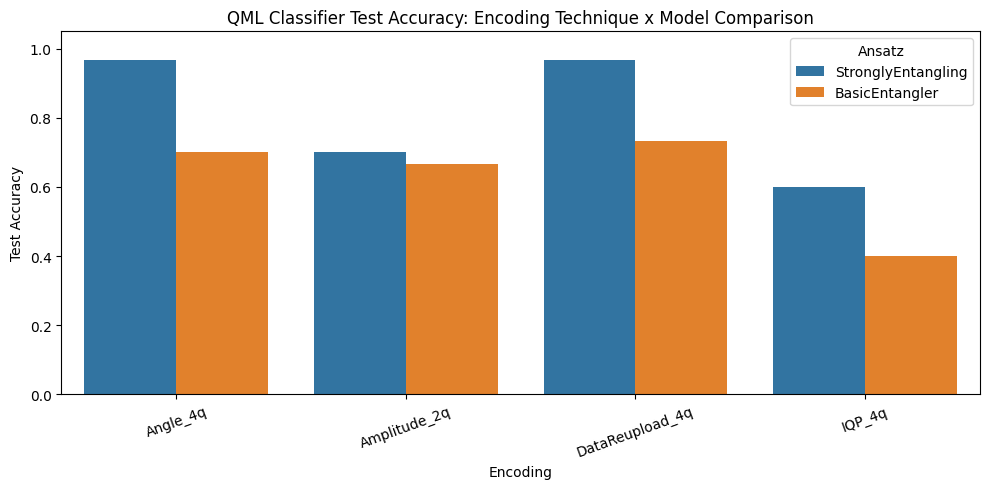

In [ ]:
print(results_df.sort_values('Test_Acc', ascending=False).to_string(index=False))

plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x='Encoding', y='Test_Acc', hue='Model')
plt.title('QML Classifier Test Accuracy: Encoding Technique x Model Comparison')
plt.ylabel('Test Accuracy')
plt.ylim(0, 1.05)
plt.xticks(rotation=20)
plt.legend(title='Ansatz')
plt.tight_layout()
plt.show()

In [ ]:
best_row = results_df.loc[results_df['Test_Acc'].idxmax()]
print("Best Encoding + Model combination:")
print(best_row)

Best Encoding + Model combination:
Encoding               Angle_4q
Model        StronglyEntangling
Train_Acc              0.933333
Test_Acc               0.966667
Name: 0, dtype: object
